In [12]:
from langchain_experimental.agents.agent_toolkits.pandas.base import create_pandas_dataframe_agent
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

In [62]:
load_dotenv()

True

In [80]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="mixtral-8x7b-32768",
    temperature=0,
    max_tokens=1024,
)

In [81]:
llm.invoke("who are you?")

AIMessage(content='I am a large language model trained by Mistral AI, a leading AI company based in Paris. I am designed to generate human-like text based on the input I receive. I do not have personal experiences or emotions, but I can mimic a conversational style and provide information on a wide range of topics. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 12, 'total_tokens': 84, 'completion_time': 0.113898969, 'prompt_time': 0.001929757, 'queue_time': 0.012550062999999998, 'total_time': 0.115828726}, 'model_name': 'mixtral-8x7b-32768', 'system_fingerprint': 'fp_c5f20b5bb1', 'finish_reason': 'stop', 'logprobs': None}, id='run-e66b0b85-3be0-4f93-8603-cb5264fad1d8-0', usage_metadata={'input_tokens': 12, 'output_tokens': 72, 'total_tokens': 84})

In [82]:
df = pd.read_csv("/Users/taidoan/Desktop/project/100pandas/100_bai_tap_pandas/data/preprocessed/product.csv")

da_agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True,
    return_intermediate_steps=True,
)
da_agent

AgentExecutor(verbose=True, agent=RunnableMultiActionAgent(runnable=RunnableAssign(mapper={
  agent_scratchpad: RunnableLambda(lambda x: message_formatter(x['intermediate_steps']))
})
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'input'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[l

In [83]:
query = "Describe this data"
response = da_agent(query)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df.describe()'}`


       category_major_cd  category_medium_cd  category_small_cd    unit_price  \
count       10030.000000        10030.000000       10030.000000  10023.000000   
mean            7.521834          758.115254       75814.855035    402.575576   
std             1.335925          133.913773       13391.360784    517.736220   
min             4.000000          401.000000       40101.000000     10.000000   
25%             7.000000          703.000000       70308.000000    155.000000   
50%             7.000000          709.000000       70903.000000    252.000000   
75%             9.000000          903.000000       90303.000000    428.000000   
max             9.000000          915.000000       91503.000000  10925.000000   

          unit_cost  
count  10023.000000  
mean     302.189464  
std      389.196815  
min        7.000000  
25%      116.000000  
50%      189.000000  
75%      32

In [84]:
response

{'input': 'Describe this data',
 'output': 'The dataframe `df` contains information about products, including their category codes and prices. The `category_major_cd` column represents the major category code, while `category_medium_cd` and `category_small_cd` represent the medium and small category codes, respectively. The `unit_price` column shows the price of each product, and the `unit_cost` column shows the cost of each product.\n\nThe dataframe has 10,030 rows and 6 columns. The `category_major_cd` column has a mean value of 7.52, a standard deviation of 1.34, and ranges from 4 to 9. The `category_medium_cd` column has a mean value of 758.12, a standard deviation of 133.91, and ranges from 401 to 915. The `category_small_cd` column has a mean value of 75814.86, a standard deviation of 13391.36, and ranges from 40101 to 91503.\n\nThe `unit_price` column has a mean value of 402.58, a standard deviation of 517.74, and ranges from 10 to 10925. The `unit_cost` column has a mean value 

In [85]:
print(response["intermediate_steps"][-1][0].tool_input['query'])

df.describe()




> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt; df['unit_price'].plot(kind='hist')"}`


Axes(0.125,0.11;0.775x0.77)The distribution of unit\_price in the dataframe `df` is visualized as a histogram using the provided tool. However, the output of the tool seems to be the Axes object, which might not be the desired output. To display the plot, you can use the following tool call:

Tool use failed: 

> Finished chain.


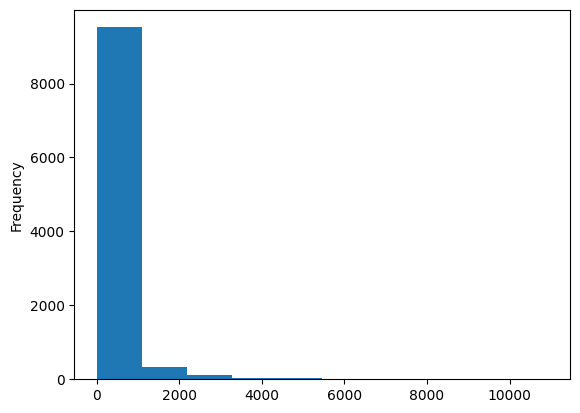

In [86]:
query = "plot distribution of unit_price "
response = da_agent(query)

In [53]:
print(response["intermediate_steps"][-1][0].tool_input['query'])

plt.show()




> Entering new AgentExecutor chain...


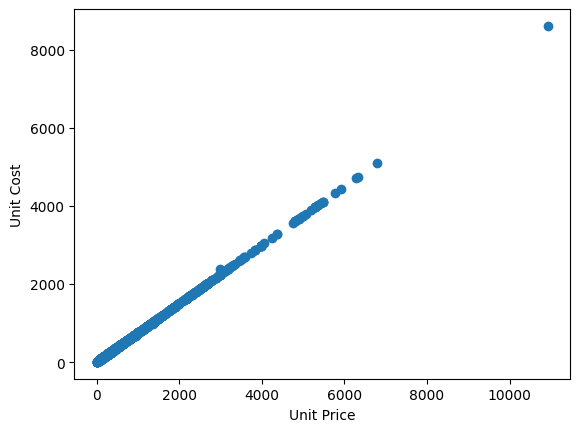


Invoking: `python_repl_ast` with `{'query': "import matplotlib.pyplot as plt\nplt.scatter(df['unit_price'], df['unit_cost'])\nplt.xlabel('Unit Price')\nplt.ylabel('Unit Cost')\nplt.show()"}`


Tool use failed: no valid JSON object found in message content

> Finished chain.


In [54]:
query = "plot a scatter  plot of unit price and unit cost"
response = da_agent(query)

In [55]:
print(response["intermediate_steps"][-1][0].tool_input['query'])

import matplotlib.pyplot as plt
plt.scatter(df['unit_price'], df['unit_cost'])
plt.xlabel('Unit Price')
plt.ylabel('Unit Cost')
plt.show()


In [56]:
!pip3 install langchain_community

In [63]:
import os
from langchain_openai import ChatOpenAI

api_key = os.environ.get("SAMBANOVA_API_KEY")

llm = ChatOpenAI(
    base_url="https://api.sambanova.ai/v1/",  
    api_key=api_key,
    streaming=True,
    model="Meta-Llama-3.1-70B-Instruct",
)

response = llm.invoke('What is the capital of France?')
print(response.content)

The capital of France is Paris.


In [64]:
df = pd.read_csv("/Users/taidoan/Desktop/project/100pandas/100_bai_tap_pandas/data/preprocessed/product.csv")

da_agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True,
    return_intermediate_steps=True,
)
da_agent

AgentExecutor(verbose=True, agent=RunnableMultiActionAgent(runnable=RunnableAssign(mapper={
  agent_scratchpad: RunnableLambda(lambda x: message_formatter(x['intermediate_steps']))
})
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'input'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[l

In [65]:
query = "Describe this data"
response = da_agent(query)



> Entering new AgentExecutor chain...
This data appears to be a product catalog with various categories and pricing information. Here's a description of each column:

1. **product_cd**: A unique identifier for each product, represented as a string. The format seems to be a combination of letters and numbers, possibly following a specific pattern or convention.
2. **category_major_cd**, **category_medium_cd**, and **category_small_cd**: These columns represent a hierarchical categorization of products, with each level becoming more specific. The values are numerical, suggesting a predefined categorization system.
	* **category_major_cd** might represent the top-level category (e.g., electronics, clothing, etc.).
	* **category_medium_cd** could represent a subcategory within the major category (e.g., electronics > smartphones).
	* **category_small_cd** might represent a further sub-subcategory (e.g., electronics > smartphones > Android phones).
3. **unit_price** and **unit_cost**: Thes

In [66]:
query = "plot distribution of unit price"
response = da_agent(query)



> Entering new AgentExecutor chain...
You can use the `matplotlib` library to plot the distribution of the `unit_price` column in your DataFrame. Here's how to do it:

```python
import matplotlib.pyplot as plt

# Create a histogram of the unit price distribution
df['unit_price'].hist(bins=50, figsize=(10, 6))

# Set the title and labels
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

# Show the plot
plt.show()
```

Alternatively, you can use the `seaborn` library to create a more informative and visually appealing plot:

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Create a histogram of the unit price distribution with a kernel density estimate (KDE)
sns.histplot(df['unit_price'], bins=50, kde=True, figsize=(10, 6))

# Set the title and labels
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

# Show the plot
plt.show()
```

Both of these methods will create a histogram of the `unit

In [67]:
print(response["intermediate_steps"][-1][0].tool_input['query'])

IndexError: list index out of range

In [68]:
response

{'input': 'plot distribution of unit price',
 'output': "You can use the `matplotlib` library to plot the distribution of the `unit_price` column in your DataFrame. Here's how to do it:\n\n```python\nimport matplotlib.pyplot as plt\n\n# Create a histogram of the unit price distribution\ndf['unit_price'].hist(bins=50, figsize=(10, 6))\n\n# Set the title and labels\nplt.title('Distribution of Unit Price')\nplt.xlabel('Unit Price')\nplt.ylabel('Frequency')\n\n# Show the plot\nplt.show()\n```\n\nAlternatively, you can use the `seaborn` library to create a more informative and visually appealing plot:\n\n```python\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Create a histogram of the unit price distribution with a kernel density estimate (KDE)\nsns.histplot(df['unit_price'], bins=50, kde=True, figsize=(10, 6))\n\n# Set the title and labels\nplt.title('Distribution of Unit Price')\nplt.xlabel('Unit Price')\nplt.ylabel('Frequency')\n\n# Show the plot\nplt.show()\n```\n\nBoth o

In [70]:
!pip3 install langchain_fireworks

In [71]:
load_dotenv()

True

In [72]:
from langchain_fireworks import ChatFireworks

llm = ChatFireworks(
    model="accounts/fireworks/models/llama-v3-70b-instruct",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [73]:
llm.invoke("who are you?")

AIMessage(content="I am LLaMA, an AI assistant developed by Meta AI that can understand and respond to human input in a conversational manner. I'm a large language model trained on a massive dataset of text from the internet, which allows me to generate human-like responses to a wide range of topics and questions.\n\nI can be used to:\n\n* Answer questions on various topics, from science and history to entertainment and culture\n* Generate text on a given topic or subject\n* Translate text from one language to another\n* Summarize long pieces of text into shorter, more digestible versions\n* Even create stories, poems, or dialogues\n\nI'm constantly learning and improving, so please bear with me if I make any mistakes. I'm here to help and provide information to the best of my abilities!", additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 14, 'total_tokens': 177, 'completion_tokens': 163}, 'model_name': 'accounts/fireworks/models/llama-v3-70b-instruct', 'system_

In [74]:
df = pd.read_csv("/Users/taidoan/Desktop/project/100pandas/100_bai_tap_pandas/data/preprocessed/product.csv")

da_agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    agent_type="tool-calling",
    allow_dangerous_code=True,
    verbose=True,
    return_intermediate_steps=True,
)
da_agent

AgentExecutor(verbose=True, agent=RunnableMultiActionAgent(runnable=RunnableAssign(mapper={
  agent_scratchpad: RunnableLambda(lambda x: message_formatter(x['intermediate_steps']))
})
| ChatPromptTemplate(input_variables=['agent_scratchpad', 'input'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[l

In [75]:
query = "plot distribution of unit price"
response = da_agent(query)



> Entering new AgentExecutor chain...
You can use the `plot` function from pandas to create a histogram of the unit price distribution. Here's the code:
```
df['unit_price'].plot(kind='hist', bins=50)
```
This will create a histogram with 50 bins, showing the distribution of unit prices in the dataframe.

If you want to customize the plot, you can use the `matplotlib` library. Here's an example:
```
import matplotlib.pyplot as plt

plt.hist(df['unit_price'], bins=50, alpha=0.5, color='skyblue')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.title('Distribution of Unit Prices')
plt.show()
```
This will create a histogram with a blue color, and add labels and a title to the plot.

> Finished chain.


In [76]:
print(response["intermediate_steps"][-1][0].tool_input['query'])

IndexError: list index out of range

In [77]:
response

{'input': 'plot distribution of unit price',
 'output': "You can use the `plot` function from pandas to create a histogram of the unit price distribution. Here's the code:\n```\ndf['unit_price'].plot(kind='hist', bins=50)\n```\nThis will create a histogram with 50 bins, showing the distribution of unit prices in the dataframe.\n\nIf you want to customize the plot, you can use the `matplotlib` library. Here's an example:\n```\nimport matplotlib.pyplot as plt\n\nplt.hist(df['unit_price'], bins=50, alpha=0.5, color='skyblue')\nplt.xlabel('Unit Price')\nplt.ylabel('Frequency')\nplt.title('Distribution of Unit Prices')\nplt.show()\n```\nThis will create a histogram with a blue color, and add labels and a title to the plot.",
 'intermediate_steps': []}